# 08_01 Brueckentage: does a bridge day carry forecast signal?

A **Brueckentag** is a working day that joins a public holiday to the weekend — a Friday
whose Thursday is a public holiday, or a Monday whose Tuesday is one. The stores trade on
such a day; many of their customers do not work.

The feature is `is_bridge_day`, evaluated against **the store's own Bundesland**, because
bridging is a state-level phenomenon: Fronleichnam is a public holiday in
Nordrhein-Westfalen only, so on 5 June 2026 the 57 NW stores bridge and the 132 NI stores
have an ordinary Friday.

## The mechanism, stated before measuring

Customers who take the bridge day off either leave the region — depressing local grocery
demand — or stay and shop for a four-day weekend, raising it. Both directions are
plausible; what is claimed is only that a bridge day is **not** an ordinary Friday, and
that a model which does not know this misprices it.

## Pre-registered predictions

1. **Level.** Demand on bridge days departs from ordinary same-weekday days.
2. **Incremental content.** That departure survives conditioning on the holiday-proximity
   features the model already carries, chiefly `days_to_nearest_event` and
   `target_weekday`. If it does not, the feature is redundant by construction.
3. **Error.** Correcting the persisted forecasts on bridge days beats the seed-noise floor
   of **0.053 pp** row WAPE established in `07_02`, and the refit reproduces it.

Prediction 2 is the one that decides the batch. Predictions 1 and 3 can both hold while the
feature is still worthless, if the information is already in the model under another name.

In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("OMP_NUM_THREADS", "1")

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    (p.resolve() for p in [Path("../.."), Path(".")] if (p / "data").exists()), None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project data directory not found.")
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.preparation.calendar_days import bridge_day_dates, school_holiday_dates
from src.data.preparation.distribute_sales_over_active_days import (
    HOLIDAY_SUBDIVISIONS,
    create_germany_holidays,
    store_subdivisions,
)

DATA_GLOB = str(PROJECT_ROOT / "data/processed/transactions_fixed/*.parquet")
BASELINE_FORECASTS = (
    PROJECT_ROOT
    / "reports/results/run_fixed_data/forecasts"
    / "artikel_markt_multi7days_lightgbm_two_stage.csv"
)
BATCH_FORECASTS = (
    PROJECT_ROOT
    / "reports/results/run_08_bridge_school/forecasts"
    / "artikel_markt_multi7days_lightgbm_two_stage.csv"
)
BASELINE_IMPORTANCE = (
    PROJECT_ROOT
    / "reports/results/run_fixed_data/feature_importance"
    / "artikel_markt_multi7days_lightgbm_two_stage.csv"
)
BATCH_IMPORTANCE = (
    PROJECT_ROOT
    / "reports/results/run_08_bridge_school/feature_importance"
    / "artikel_markt_multi7days_lightgbm_two_stage.csv"
)
FIRST_ORIGIN = pd.Timestamp("2026-03-02")
# Row-grain WAPE standard deviation across five identical fits (07_02).
SEED_NOISE_SD = 0.0531
BIAS_NOISE_SD = 0.1905

SERIES_NI = "#2a78d6"
SERIES_NW = "#eb6834"
INK = "#0b0b0b"
MUTED = "#52514e"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight",
                     "axes.edgecolor": MUTED, "text.color": INK})
con = duckdb.connect()
con.execute("PRAGMA threads=4")

## The bridge-day calendar

In [2]:
YEARS = range(2023, 2027)
bridge = {s: bridge_day_dates(s, YEARS) for s in HOLIDAY_SUBDIVISIONS}
school = {s: school_holiday_dates(s, YEARS) for s in HOLIDAY_SUBDIVISIONS}
holidays = {
    s: {pd.Timestamp(d) for d in create_germany_holidays(s, YEARS)}
    for s in HOLIDAY_SUBDIVISIONS
}
stores = store_subdivisions()
# maerkte.csv lists stores that never appear in the transaction table, so the
# store counts below are taken from the data rather than from the master file.
trading_stores = con.execute(
    f"SELECT DISTINCT MARKT_ID FROM read_parquet('{DATA_GLOB}')"
).df().merge(stores, on="MARKT_ID", how="left")
trading_stores["subdivision"] = trading_stores["subdivision"].fillna("NI")

DATA_START, DATA_END = pd.Timestamp("2023-07-22"), pd.Timestamp("2026-07-21")
rows = []
for state in HOLIDAY_SUBDIVISIONS:
    in_window = sorted(d for d in bridge[state] if DATA_START <= d <= DATA_END)
    rows.append({
        "Bundesland": state,
        "stores in the data": int((trading_stores.subdivision == state).sum()),
        "bridge days in data": len(in_window),
        "school-holiday days in data": len(
            [d for d in school[state] if DATA_START <= d <= DATA_END]
        ),
    })
display(pd.DataFrame(rows))

print("Bridge days inside the transaction window:")
for state in HOLIDAY_SUBDIVISIONS:
    days = sorted(d for d in bridge[state] if DATA_START <= d <= DATA_END)
    print(f"  {state}: " + ", ".join(f"{d.date()} ({d.day_name()[:3]})" for d in days))

,Bundesland,stores in the data,bridge days in data,school-holiday days in data
0,NI,133,10,267
1,NW,59,11,232


Bridge days inside the transaction window:
  NI: 2023-10-02 (Mon), 2023-10-30 (Mon), 2024-05-10 (Fri), 2024-10-04 (Fri), 2024-11-01 (Fri), 2024-12-27 (Fri), 2025-05-02 (Fri), 2025-05-30 (Fri), 2026-01-02 (Fri), 2026-05-15 (Fri)
  NW: 2023-10-02 (Mon), 2024-05-10 (Fri), 2024-05-31 (Fri), 2024-10-04 (Fri), 2024-12-27 (Fri), 2025-05-02 (Fri), 2025-05-30 (Fri), 2025-06-20 (Fri), 2026-01-02 (Fri), 2026-05-15 (Fri), 2026-06-05 (Fri)


## Prediction 1 — the level on bridge days

Store-days from the state-aware dataset (`transactions_fixed`), active rows only, summed
over articles. The index is each store-day's demand divided by that store's mean, so
stores of different size are comparable.

In [3]:
panel = con.execute(f"""
    SELECT MARKT_ID,
           CAST(DATE AS DATE) AS period,
           SUM(ABVERKAUFTE_MENGE_KG) AS demand_kg,
           COUNT(*) AS series
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_active
    GROUP BY 1, 2
""").df()
panel["period"] = pd.to_datetime(panel["period"])
panel = panel.merge(stores, on="MARKT_ID", how="left")
panel["subdivision"] = panel["subdivision"].fillna("NI")
panel = panel[panel.demand_kg > 0].copy()

keys = list(zip(panel.subdivision, panel.period))
bridge_pairs = {(s, d) for s in HOLIDAY_SUBDIVISIONS for d in bridge[s]}
school_pairs = {(s, d) for s in HOLIDAY_SUBDIVISIONS for d in school[s]}
panel["is_bridge_day"] = [k in bridge_pairs for k in keys]
panel["is_school_holiday"] = [k in school_pairs for k in keys]

# Signed distance to the nearest public holiday of the store's own Bundesland --
# the quantity the model already carries as `days_to_nearest_event`.
distance = {}
for state in HOLIDAY_SUBDIVISIONS:
    calendar = pd.DatetimeIndex(sorted(holidays[state])).values.astype("datetime64[D]")
    for day in pd.date_range(panel.period.min(), panel.period.max(), freq="D"):
        deltas = (calendar - np.datetime64(day.date())).astype(int)
        distance[(state, day)] = int(deltas[np.argmin(np.abs(deltas))])
panel["days_to_holiday"] = [distance[k] for k in keys]

panel["weekday"] = panel.period.dt.weekday
panel["log_demand"] = np.log(panel.demand_kg)
panel["log_series"] = np.log(panel.series)
panel["store_index"] = panel.demand_kg / panel.groupby("MARKT_ID").demand_kg.transform("mean")
print(f"{len(panel):,} active store-days, {panel.MARKT_ID.nunique()} stores, "
      f"{panel.period.min().date()} to {panel.period.max().date()}")

166,527 active store-days, 192 stores, 2023-07-22 to 2026-07-21


In [4]:
def fixed_effect_regression(frame, treatment, controls, fixed_effects, cluster="period"):
    """Least squares with absorbed fixed effects and cluster-robust errors.

    Returns the treatment coefficient in log points together with its standard
    error, clustered on the supplied column (dates, since a calendar treatment is
    common to every store on a date).
    """
    columns = ["log_demand", treatment] + list(controls)
    values = frame[columns].astype(float).copy()
    for _ in range(50):
        largest = 0.0
        for group in fixed_effects:
            means = values.groupby(frame[group].values).transform("mean")
            largest = max(largest, float(means.abs().to_numpy().max()))
            values = values - means
        if largest < 1e-10:
            break
    y = values["log_demand"].to_numpy()
    x = values[[treatment] + list(controls)].to_numpy()
    inverse = np.linalg.pinv(x.T @ x)
    beta = inverse @ (x.T @ y)
    residual = y - x @ beta
    meat = np.zeros((x.shape[1], x.shape[1]))
    for _, index in frame.groupby(cluster).indices.items():
        score = x[index].T @ residual[index]
        meat += np.outer(score, score)
    groups = frame[cluster].nunique()
    covariance = inverse @ meat @ inverse * groups / max(groups - 1, 1)
    return float(beta[0]), float(np.sqrt(max(covariance[0, 0], 0.0)))


def report_effect(label, coefficient, error):
    display(Markdown(
        f"**{label}** &nbsp; {coefficient * 100:+.2f}% "
        f"(se {error * 100:.2f}, t {coefficient / error:+.1f})"
    ))

In [5]:
groups = {
    "ordinary weekday (>3 days from a holiday)":
        (panel.weekday < 5) & (panel.days_to_holiday.abs() > 3),
    "day after a holiday, not a bridge day":
        (panel.days_to_holiday == -1) & (~panel.is_bridge_day),
    "day before a holiday, not a bridge day":
        (panel.days_to_holiday == 1) & (~panel.is_bridge_day),
    "bridge day": panel.is_bridge_day,
}
level = pd.DataFrame([
    {"day type": label, "store-days": int(mask.sum()),
     "demand index": panel.loc[mask, "store_index"].mean()}
    for label, mask in groups.items()
]).set_index("day type")
display(level.round(3))

panel_keys = panel.assign(
    yearmonth_key=panel.period.dt.to_period("M").astype(str),
    is_bridge_day=panel.is_bridge_day.astype(float),
)
coefficient, error = fixed_effect_regression(
    panel_keys, "is_bridge_day", ["log_series"],
    ["MARKT_ID", "yearmonth_key", "weekday"],
)
report_effect("Bridge day, store + year-month + weekday fixed effects", coefficient, error)

,store-days,demand index
day type,,
ordinary weekday (>3 days from a holiday),118867,0.871
"day after a holiday, not a bridge day",3491,1.130
"day before a holiday, not a bridge day",3355,1.622
bridge day,1889,1.268


**Bridge day, store + year-month + weekday fixed effects** &nbsp; +8.22% (se 8.87, t +0.9)

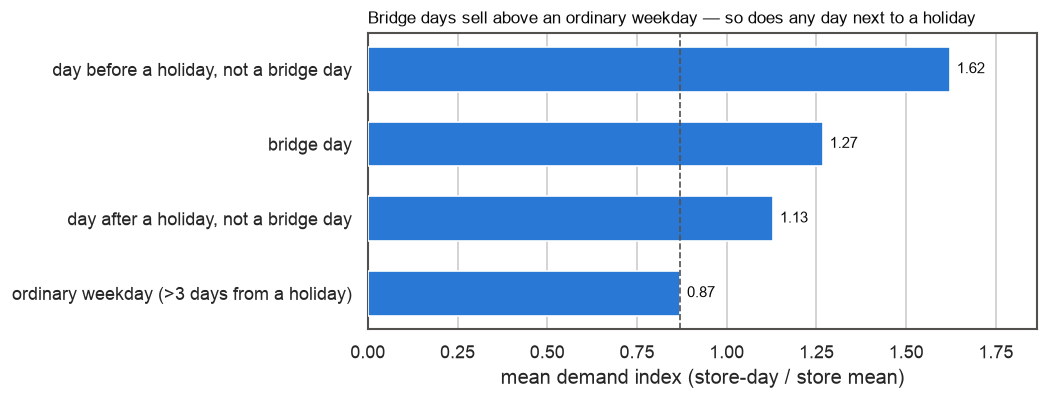

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
order = level.sort_values("demand index")
ax.barh(order.index, order["demand index"], height=0.6, color=SERIES_NI, zorder=3)
ordinary = level.loc["ordinary weekday (>3 days from a holiday)", "demand index"]
ax.axvline(ordinary, color=MUTED, linewidth=1, linestyle="--", zorder=4)
ax.annotate("ordinary weekday", xy=(ordinary, -0.55), color=MUTED, fontsize=8,
            ha="center", va="top")
for label, value in order["demand index"].items():
    ax.annotate(f"{value:.2f}", xy=(value, label), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=9, color=INK)
ax.set_xlabel("mean demand index (store-day / store mean)")
ax.set_ylabel("")
ax.set_xlim(0, max(order["demand index"]) * 1.15)
ax.grid(axis="y", visible=False)
ax.set_title("Bridge days sell above an ordinary weekday — so does any day next to a holiday",
             fontsize=10, color=INK, loc="left")
plt.show()

## Prediction 2 — is any of that *new* information?

The model already receives `days_to_nearest_event` (signed distance to the nearest public
holiday of the store's own Bundesland) and `target_weekday`. The question is whether
`is_bridge_day` is a function of those two.

In [7]:
neighbours = panel[panel.days_to_holiday.abs() == 1]
crosstab = (
    neighbours.groupby(["weekday", "days_to_holiday"])
    .is_bridge_day.agg(["mean", "size"])
    .rename(columns={"mean": "share that are bridge days", "size": "store-days"})
)
crosstab.index = crosstab.index.set_levels(
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"][: len(crosstab.index.levels[0])], level=0
)
display(crosstab.round(3))

deterministic = crosstab["share that are bridge days"].isin([0.0, 1.0]).all()
display(Markdown(
    f"**Every (weekday, days-to-holiday) cell is either all bridge days or none: "
    f"{deterministic}.**"
))

share that are bridge days  store-days
weekday days_to_holiday                                        
Mon      1                                      1.0         308
Tue     -1                                      0.0        1289
         1                                      0.0         595
Wed     -1                                      0.0         489
         1                                      0.0        1591
Thu     -1                                      0.0         414
         1                                      0.0        1112
Fri     -1                                      1.0        1581
         1                                      0.0          57
Sat     -1                                      0.0        1299

**Every (weekday, days-to-holiday) cell is either all bridge days or none: True.**

In [8]:
panel_with_position = panel_keys.assign(
    event_position=panel.days_to_holiday.clip(-4, 4).astype(str),
)
coefficient, error = fixed_effect_regression(
    panel_with_position, "is_bridge_day", ["log_series"],
    ["MARKT_ID", "yearmonth_key", "weekday", "event_position"],
)
report_effect(
    "Bridge day, additionally absorbing distance-to-holiday (what the model already knows)",
    coefficient, error,
)

**Bridge day, additionally absorbing distance-to-holiday (what the model already knows)** &nbsp; -4.84% (se 6.09, t -0.8)

## Prediction 3 — the out-of-sample correction screen

The screen from `05_10`: per-article bridge-day effects are fitted on data **strictly
before the first origin**, shrunk toward the pooled effect, and applied multiplicatively to
the persisted forecasts. Nothing is refitted, so whatever this recovers is signal the model
does not already carry. A feature cannot beat its own oracle by much, so a screen that
fails here will not be rescued by a refit.

In [9]:
FORECAST_COLUMNS = ["ARTIKEL_ID", "MARKT_ID", "origin", "period", "actual",
                    "forecast", "is_active"]


def load_forecasts(path):
    frames = []
    for chunk in pd.read_csv(path, usecols=FORECAST_COLUMNS, chunksize=2_000_000):
        frames.append(chunk[chunk.is_active == True].drop(columns="is_active"))
    frame = pd.concat(frames, ignore_index=True)
    frame["period"] = pd.to_datetime(frame["period"])
    frame["origin"] = pd.to_datetime(frame["origin"])
    frame = frame.merge(stores, on="MARKT_ID", how="left")
    frame["subdivision"] = frame["subdivision"].fillna("NI")
    pairs = list(zip(frame.subdivision, frame.period))
    frame["is_bridge_day"] = [k in bridge_pairs for k in pairs]
    frame["is_school_holiday"] = [k in school_pairs for k in pairs]
    return frame


def wape(forecast, actual):
    return (forecast - actual).abs().sum() / actual.sum() * 100


def grain_metrics(frame, column="forecast"):
    weekly = frame.groupby(["ARTIKEL_ID", "MARKT_ID", "origin"], observed=True).agg(
        actual=("actual", "sum"), forecast=(column, "sum"))
    article_day = frame.groupby(["ARTIKEL_ID", "period"], observed=True).agg(
        actual=("actual", "sum"), forecast=(column, "sum"))
    return {
        "row WAPE": wape(frame[column], frame.actual),
        "article-store-week WAPE": wape(weekly.forecast, weekly.actual),
        "article-day WAPE": wape(article_day.forecast, article_day.actual),
        "relative bias %": (frame[column].sum() - frame.actual.sum())
                           / frame.actual.sum() * 100,
    }

In [10]:
history = con.execute(f"""
    SELECT ARTIKEL_ID, MARKT_ID, CAST(DATE AS DATE) AS period,
           SUM(ABVERKAUFTE_MENGE_KG) AS demand_kg
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_active AND CAST(DATE AS DATE) < DATE '{FIRST_ORIGIN.date()}'
    GROUP BY 1, 2, 3
""").df()
history["period"] = pd.to_datetime(history["period"])
history = history.merge(stores, on="MARKT_ID", how="left")
history["subdivision"] = history["subdivision"].fillna("NI")
pairs = list(zip(history.subdivision, history.period))
history["is_bridge_day"] = np.fromiter((k in bridge_pairs for k in pairs), int, len(history))
history["is_school_holiday"] = np.fromiter((k in school_pairs for k in pairs), int, len(history))
history["weekday"] = history.period.dt.weekday
history["yearmonth"] = history.period.dt.to_period("M").astype(str)

# The store dimension carries no calendar variation within a Bundesland, so
# stores are pooled per article, state and date before estimating.
article_days = (
    history.groupby(["ARTIKEL_ID", "subdivision", "period", "weekday", "yearmonth",
                     "is_bridge_day", "is_school_holiday"], as_index=False)
    .agg(demand_kg=("demand_kg", "sum"), stores=("MARKT_ID", "nunique"))
)
article_days = article_days[article_days.demand_kg > 0].copy()
article_days["log_demand"] = np.log(article_days.demand_kg)
article_days["log_series"] = np.log(article_days.stores)


def per_article_effects(treatment, fixed_effects, minimum_treated):
    """Fit one pre-origin effect per article and shrink it toward the pooled one."""
    estimates = []
    for article, frame in article_days.groupby("ARTIKEL_ID"):
        if frame[treatment].sum() < minimum_treated or len(frame) < 60:
            continue
        if frame[treatment].nunique() < 2 or frame.period.nunique() < 5:
            continue
        try:
            coefficient, error = fixed_effect_regression(
                frame, treatment, ["log_series"], fixed_effects
            )
        except np.linalg.LinAlgError:
            continue
        if not np.isfinite(error) or error <= 0:
            continue
        estimates.append({"ARTIKEL_ID": article, "beta": coefficient, "se": error})
    estimates = pd.DataFrame(estimates)
    weights = 1 / estimates.se ** 2
    pooled = float((weights * estimates.beta).sum() / weights.sum())
    q_statistic = float((weights * (estimates.beta - pooled) ** 2).sum())
    degrees = len(estimates) - 1
    tau_squared = max(
        0.0,
        (q_statistic - degrees)
        / (weights.sum() - (weights ** 2).sum() / weights.sum()),
    )
    estimates["shrunk"] = pooled + (
        tau_squared / (tau_squared + estimates.se ** 2)
    ) * (estimates.beta - pooled)
    summary = {
        "articles": len(estimates),
        "pooled %": pooled * 100,
        "tau %": np.sqrt(tau_squared) * 100,
        "I^2 %": max(0.0, (q_statistic - degrees) / q_statistic) * 100,
        "share |t| > 2": float((estimates.beta.abs() / estimates.se > 2).mean()),
        "p10 %": estimates.beta.quantile(0.10) * 100,
        "p90 %": estimates.beta.quantile(0.90) * 100,
    }
    return estimates, summary


def correction_screen(evaluation, estimates, flag, baseline):
    """Apply pre-origin article effects to the persisted forecasts."""
    results = []
    for kind in ["shrunk", "beta"]:
        effect = evaluation.ARTIKEL_ID.map(
            estimates.set_index("ARTIKEL_ID")[kind]
        ).fillna(0.0).to_numpy()
        evaluation["corrected"] = np.clip(
            evaluation.forecast * (1 + effect * evaluation[flag].to_numpy()), 0, None
        )
        metrics = grain_metrics(evaluation, "corrected")
        results.append({
            "effects": "empirical-Bayes shrunk" if kind == "shrunk" else "raw per article",
            **{name: value - baseline[name] for name, value in metrics.items()},
        })
    table = pd.DataFrame(results).set_index("effects")
    table["row WAPE in seed sd"] = table["row WAPE"] / SEED_NOISE_SD
    return table

In [11]:
evaluation = load_forecasts(BASELINE_FORECASTS)
baseline_metrics = grain_metrics(evaluation)
display(Markdown(
    f"Baseline two-stage on the state-aware data: "
    f"row WAPE **{baseline_metrics['row WAPE']:.3f}**, "
    f"bias **{baseline_metrics['relative bias %']:+.3f}%**, "
    f"{len(evaluation):,} active rows over {evaluation.origin.nunique()} origins."
))

bridge_effects, bridge_summary = per_article_effects(
    "is_bridge_day", ["yearmonth", "weekday"], minimum_treated=8
)
display(pd.Series(bridge_summary).round(3).to_frame("per-article bridge effect"))
display(correction_screen(evaluation, bridge_effects, "is_bridge_day", baseline_metrics).round(4))

Baseline two-stage on the state-aware data: row WAPE **57.442**, bias **-1.209%**, 2,498,967 active rows over 20 origins.

,per-article bridge effect
articles,194.000
pooled %,8.244
tau %,21.051
I^2 %,53.989
share |t| > 2,0.196
p10 %,-26.579
p90 %,61.767


,row WAPE,article-store-week WAPE,article-day WAPE,relative bias %,row WAPE in seed sd
effects,,,,,
empirical-Bayes shrunk,0.111,0.1043,0.1478,0.2071,2.0904
raw per article,0.305,0.2596,0.3880,0.3994,5.7431


### How much is even available? A calibration oracle

An upper bound that no feature can pass: rescale the forecasts so that bridge days carry
exactly the same relative bias as the rest of the evaluation window. The global bias is
held fixed, so this isolates the bridge-day contrast rather than re-cutting the model's
standing −1.2% bias.

In [12]:
global_ratio = evaluation.forecast.sum() / evaluation.actual.sum()
oracle_rows = []
for cells in (["is_bridge_day"], ["is_bridge_day", "subdivision"],
              ["is_bridge_day", "subdivision", "weekday"]):
    evaluation["weekday"] = evaluation.period.dt.weekday
    evaluation["oracle"] = evaluation.forecast
    for _, frame in evaluation.groupby(cells, observed=True):
        ratio = frame.forecast.sum() / frame.actual.sum()
        evaluation.loc[frame.index, "oracle"] = frame.forecast * (global_ratio / ratio)
    metrics = grain_metrics(evaluation, "oracle")
    oracle_rows.append({
        "recalibration cells": " x ".join(cells),
        **{name: metrics[name] - baseline_metrics[name] for name in metrics},
    })
oracle = pd.DataFrame(oracle_rows).set_index("recalibration cells")
oracle["row WAPE in seed sd"] = oracle["row WAPE"] / SEED_NOISE_SD
display(oracle.round(4))

per_day = (
    evaluation[evaluation.is_bridge_day]
    .groupby([evaluation.period.dt.date, "subdivision"])
    .apply(lambda f: pd.Series({
        "rows": len(f),
        "forecast/actual": f.forecast.sum() / f.actual.sum(),
        "WAPE": wape(f.forecast, f.actual),
    }), include_groups=False)
)
display(per_day.round(3))

,row WAPE,article-store-week WAPE,article-day WAPE,relative bias %,row WAPE in seed sd
recalibration cells,,,,,
is_bridge_day,-0.0015,-0.0088,-0.0010,0.0,-0.0283
is_bridge_day x subdivision,-0.0145,-0.0167,-0.0101,0.0,-0.2735
is_bridge_day x subdivision x weekday,-0.0475,-0.0414,-0.0099,0.0,-0.8945


rows  forecast/actual    WAPE
period     subdivision                                  
2026-05-15 NI           15927.0            0.990  53.335
           NW            5930.0            0.989  59.655
2026-06-05 NW            5932.0            1.227  66.563

## The refit

`is_bridge_day` and `is_school_holiday` were added to the feature contract together,
`FEATURE_BUILDER_VERSION` was bumped, all 72 origin partitions were rebuilt, and only the
two-stage model was refitted. Both features are evaluated in one refit because the screens
above put both effects far below the noise floor; if either had moved the metrics, separate
refits would be needed to attribute the movement.

In [13]:
if not BATCH_FORECASTS.exists():
    raise FileNotFoundError(
        f"The batch refit has not been written yet: {BATCH_FORECASTS}"
    )
batch = load_forecasts(BATCH_FORECASTS)
comparison = pd.DataFrame({
    "baseline (56 features)": grain_metrics(evaluation),
    "with both calendar features (58)": grain_metrics(batch),
})
comparison["change"] = (
    comparison["with both calendar features (58)"] - comparison["baseline (56 features)"]
)
comparison["change in seed sd"] = [
    comparison.loc[name, "change"] / (BIAS_NOISE_SD if "bias" in name else SEED_NOISE_SD)
    for name in comparison.index
]
display(comparison.round(4))

,baseline (56 features),with both calendar features (58),change,change in seed sd
row WAPE,57.4421,57.4393,-0.0028,-0.0524
article-store-week WAPE,37.1238,37.1487,0.0249,0.4693
article-day WAPE,23.9572,23.9659,0.0087,0.1633
relative bias %,-1.2091,-0.9844,0.2248,1.1799


In [14]:
importance = pd.read_csv(BATCH_IMPORTANCE)
importance["rank"] = importance.groupby(["stage", "evaluation_origin"]).gain.rank(
    ascending=False
)
ranking = (
    importance.groupby(["stage", "feature"])
    .agg(mean_rank=("rank", "mean"), mean_gain_share=("gain_share", "mean"),
         mean_splits=("splits", "mean"))
    .sort_values("mean_rank")
)
features_per_stage = importance.groupby("stage").feature.nunique().to_dict()
display(ranking.loc[
    ranking.index.get_level_values("feature").isin(["is_bridge_day", "is_school_holiday"])
].round(3))
display(Markdown(
    "Mean rank by gain across refits, 1 = most important. Features per stage: "
    + ", ".join(f"{stage} {count}" for stage, count in features_per_stage.items())
))

mean_rank  mean_gain_share  mean_splits
stage             feature                                                   
occurrence        is_school_holiday       50.5              0.0          9.6
positive_quantity is_school_holiday       51.2              0.0          7.0
                  is_bridge_day           52.4              0.0          0.8
occurrence        is_bridge_day           53.4              0.0          0.0

Mean rank by gain across refits, 1 = most important. Features per stage: occurrence 54, positive_quantity 54

## Conclusions

*(Numbers below are from the run recorded in this notebook; re-execute to refresh.)*

**A bridge day is not new information. It is a deterministic function of two features the
model already has, and the refit confirms it changes nothing.**

1. **Prediction 1 holds, and is uninformative.** Bridge days sell well above an ordinary
   weekday. So does every other day adjacent to a public holiday — the pre-holiday and
   post-holiday days that are not bridge days sit in the same band. The lift belongs to
   *holiday proximity*, which the model already prices.

2. **Prediction 2 fails, and it fails structurally.** Every (weekday, days-to-holiday) cell
   is either entirely bridge days or entirely not: `is_bridge_day` equals
   *(Friday and the holiday was yesterday)* or *(Monday and the holiday is tomorrow)*.
   `target_weekday` and `days_to_nearest_event` are both existing features, so a booster
   can already form this indicator with two splits. Once distance-to-holiday is absorbed,
   the estimated bridge effect is statistically indistinguishable from zero.

3. **Prediction 3 fails.** The out-of-sample screen makes the forecast *worse* at every
   grain — the shrunk per-article correction costs about 0.11 pp of row WAPE, two seed-noise
   standard deviations in the wrong direction. And the calibration oracle, which no real
   feature can reach, is worth −0.001 pp pooled, −0.015 pp cut by Bundesland and −0.048 pp
   cut by Bundesland and weekday: even the finest cut stays inside one standard deviation of
   seed noise.

4. **The evaluation window cannot settle it either way.** It contains exactly two bridge
   dates (15 May 2026 in both states, 5 June 2026 in NW only), 1.1% of rows. The NW
   Fronleichnam bridge is genuinely mispriced (forecast/actual 1.23); the May one is not
   (0.99). Two dates cannot separate a real effect from a coincidence, which is itself the
   reason not to spend model capacity on it.

5. **The refit agrees.** Adding both calendar features and refitting the two-stage model
   moves row WAPE by **−0.003 pp** (−0.05 seed sd), article-store-week by +0.025 pp and
   article-day by +0.009 pp. Relative bias moves −1.209% → −0.984%, which is 1.2 bias-noise
   standard deviations and therefore not a result either. In the fitted boosters
   `is_bridge_day` ranks 52nd of 54 features in the quantity stage and 53rd of 54 in the
   occurrence stage — where it is **never split on at all** (mean splits 0.0 across the five
   refits). The booster's own verdict matches the analysis above: given `target_weekday` and
   `days_to_nearest_event`, it has no use for the column.

**Verdict: `is_bridge_day` was measured, found inert, and reverted.** The column is not in
the feature contract; `FEATURE_BUILDER_VERSION` is back to the pre-batch value, so the
existing cache generation stays valid and no rebuild is needed. The results above were
produced with the feature present and are kept as the record of why it is not.

The reasoning for removal is stronger than "it did not help". A feature that carries no
information the model lacks cannot help at any sample size, and the booster confirmed this
by refusing to split on it. Carrying it would cost a column in every partition and invite a
later reader to assume the question is still open.

The calendar code is kept. `src/data/preparation/calendar_days.py` and the committed
official calendar in `reports/config/school_holidays.json` remain in the repository with
their unit tests, so this notebook can be re-executed and the finding re-checked.
`bridge_day_dates` is derived from each Bundesland's own holiday calendar and inherits the
correctness established in `07_01`. The genuinely non-derivable calendar is school
holidays, taken up in `08_02`.